<a href="https://colab.research.google.com/github/mmuputisi/Adv-Py_Data_Analysis/blob/main/LenCap_supply_plan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-1-1975142571>:108: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(gantt_df['Task'].unique()))


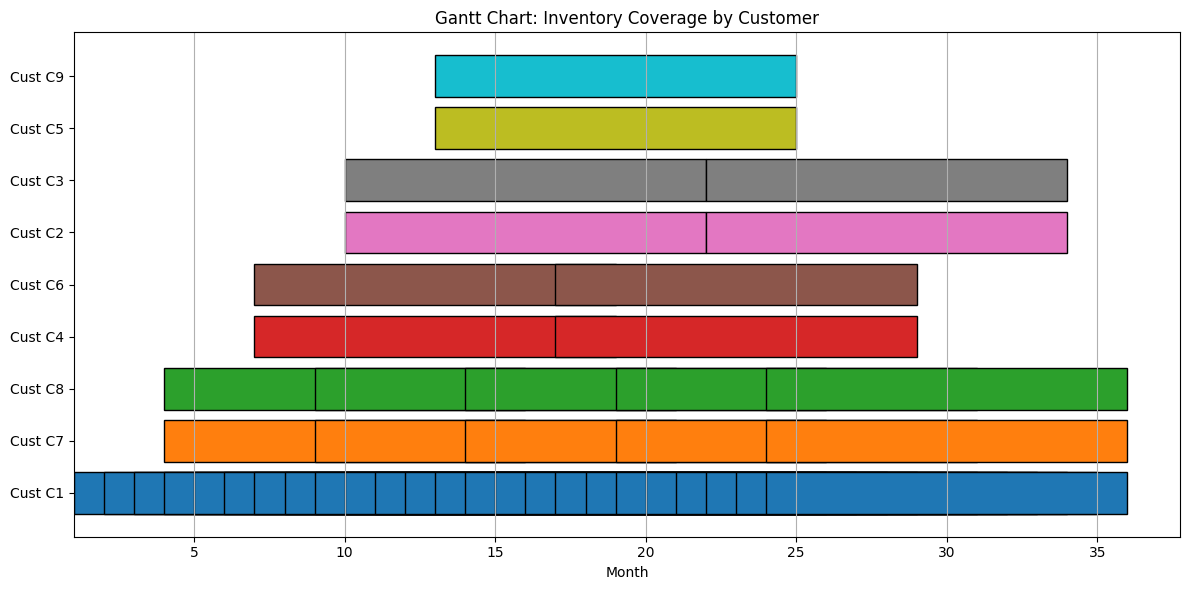

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.4/169.4 kB 4.2 MB/s eta 0:00:00

✅ Excel file saved as: Monthly_Production_Plan.xlsx

🔁 Shared Production Batches (Shelf Life = 12 months):
Batch 1: every 1 months — customers: ['C1'] — size ≈ 2.17 MOQ
Batch 2: every 5 months — customers: ['C7', 'C8'] — size ≈ 1.83 MOQ
Batch 3: every 10 months — customers: ['C4', 'C6'] — size ≈ 2.00 MOQ
Batch 4: every 12 months — customers: ['C2', 'C3'] — size ≈ 1.00 MOQ
Batch 5: every 12 months — customers: ['C5', 'C9'] — size ≈ 1.20 MOQ

📆 Monthly Production Plan (First 24 Months):

Month 1:
  Produce Batch 1 → Customers: ['C1'] | Size: 2.17 MOQ

Month 2:
  Produce Batch 2 → Customers: ['C1'] | Size: 2.17 MOQ

Month 3:
  Produce Batch 3 → Customers: ['C1'] | Size: 2.17 MOQ

Month 4:
  Produce Batch 4 → Customers: ['C1'] | Size: 2.17 MOQ
  Produce Batch 25 → Customers: ['C7', 'C8'] | Size: 1.83 MOQ

Month 5:
  Produce Batch 5 → Customers: ['C1'] | Size: 2.17 MOQ

Month 6:
  Produce Batch 6 → Customers: [

In [1]:
import pandas as pd
import math
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Parameters
SHELF_LIFE = 12  # months
TOTAL_MONTHS = 24  # time horizon for planning

# Customer 6-monthly demands (in MOQ units)
demands_6mo = {
    'C1': 13.0,
    'C2': 0.3,
    'C3': 0.2,
    'C4': 0.6,
    'C5': 0.1,
    'C6': 0.6,
    'C7': 1.3,
    'C8': 0.9,
    'C9': 0.5
}

# Step 1: Convert to monthly demand
monthly_demand = {k: v / 6 for k, v in demands_6mo.items()}

# Step 2: Determine max cycle length for each customer (based on shelf life and MOQ)
cycle_limits = {}
for cust, rate in monthly_demand.items():
    min_cycle = math.ceil(1 / rate)  # minimum months needed to hit 1 MOQ
    max_cycle = min(min_cycle, SHELF_LIFE)
    cycle_limits[cust] = max_cycle

# Step 3: Greedy grouping of customers into batches
sorted_customers = sorted(cycle_limits.items(), key=lambda x: x[1])
batches = []
used = set()

for i, (cust, max_cycle) in enumerate(sorted_customers):
    if cust in used:
        continue
    group = [cust]
    cycle = max_cycle
    total_demand = monthly_demand[cust] * cycle

    for j in range(i + 1, len(sorted_customers)):
        other_cust, other_cycle = sorted_customers[j]
        if other_cust in used:
            continue
        if other_cycle >= cycle:
            projected = monthly_demand[other_cust] * cycle
            if total_demand + projected <= 2.0:
                group.append(other_cust)
                total_demand += projected
        if total_demand >= 1.0:
            break

    batches.append({
        "customers": group,
        "cycle": cycle,
        "batch_size": round(total_demand, 2)
    })
    used.update(group)

# Step 4: Stagger batch start months and assign unique batch instances
production_plan = []
start_offsets = [0] + list(range(3, len(batches) * 3, 3))  # staggered starts
batch_instance_id = 1

for idx, batch in enumerate(batches):
    start_month = 1 + start_offsets[idx % len(start_offsets)]
    for m in range(start_month, TOTAL_MONTHS + 1, batch["cycle"]):
        production_plan.append({
            "Month": m,
            "Batch Instance ID": batch_instance_id,
            "Original Group ID": idx + 1,
            "Customers": batch["customers"],
            "Batch Size": batch["batch_size"]
        })
        batch_instance_id += 1


# Step 5: Build production and Gantt data from updated plan
schedule_records = []
gantt_records = []

for entry in production_plan:
    for cust in entry["Customers"]:
        schedule_records.append({
            "Month": entry["Month"],
            "Batch ID": entry["Batch Instance ID"],
            "Customer": cust,
            "Batch Size": entry["Batch Size"]
        })
        gantt_records.append({
            "Task": f"Cust {cust}",
            "Start": entry["Month"],
            "Finish": entry["Month"] + SHELF_LIFE,
            "Batch ID": entry["Batch Instance ID"]
        })


schedule_df = pd.DataFrame(schedule_records)
gantt_df = pd.DataFrame(gantt_records)

# Plot Gantt chart
plt.figure(figsize=(12, 6))
colors = plt.cm.get_cmap('tab10', len(gantt_df['Task'].unique()))
task_colors = {task: colors(i % 10) for i, task in enumerate(gantt_df['Task'].unique())}

for _, row in gantt_df.iterrows():
    plt.barh(row['Task'], row['Finish'] - row['Start'], left=row['Start'],
             color=task_colors[row['Task']], edgecolor='black')

plt.xlabel("Month")
plt.title("Gantt Chart: Inventory Coverage by Customer")
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

# Step 6: Save Excel file
try:
    import xlsxwriter
except ImportError:
    !pip install xlsxwriter

excel_path = "Monthly_Production_Plan.xlsx"
with pd.ExcelWriter(excel_path, engine='xlsxwriter') as writer:
    schedule_df.to_excel(writer, sheet_name='Production Plan', index=False)
    gantt_df.to_excel(writer, sheet_name='Inventory Windows', index=False)

print(f"\n✅ Excel file saved as: {excel_path}")

# Step 7: Output results
print("\n🔁 Shared Production Batches (Shelf Life = 12 months):")
for i, batch in enumerate(batches):
    print(f"Batch {i+1}: every {batch['cycle']} months — customers: {batch['customers']} — size ≈ {batch['batch_size']:.2f} MOQ")

print("\n📆 Monthly Production Plan (First 24 Months):")
df_monthly = pd.DataFrame(production_plan)
for month in range(1, TOTAL_MONTHS + 1):
    monthly_batches = df_monthly[df_monthly["Month"] == month]
    if not monthly_batches.empty:
        print(f"\nMonth {month}:")
        for _, row in monthly_batches.iterrows():
            print(f"  Produce Batch {row['Batch Instance ID']} → Customers: {row['Customers']} | Size: {row['Batch Size']} MOQ")

# Step 8: Capacity utilization analysis
print("\n📊 Monthly Capacity Utilization (Batches per Month):")

# Create a DataFrame from production_plan
df_monthly = pd.DataFrame(production_plan)

# Count number of batch instances per month
utilization = df_monthly.groupby("Month")["Batch Instance ID"].count().reset_index()
utilization.columns = ["Month", "Batches_Produced"]

# Compute summary stats
average_batches = utilization["Batches_Produced"].mean()
max_batches = utilization["Batches_Produced"].max()
min_batches = utilization["Batches_Produced"].min()

# Display monthly details
for _, row in utilization.iterrows():
    print(f"Month {int(row['Month'])}: {row['Batches_Produced']} batch(es)")

# Summary
print("\n📈 Summary:")
print(f"Average batches per month: {average_batches:.2f}")
print(f"Max batches in a month: {max_batches}")
print(f"Min batches in a month: {min_batches}")

# Optionally export to Excel
utilization.to_excel("Monthly_Batch_Utilization.xlsx", index=False)
print("\n✅ Capacity utilization report saved to: Monthly_Batch_Utilization.xlsx")